## Часть 1. Работа с датасетом

### <font color='#F5DEB3'> 1. Подключение библиотек и первичный анализ данных

*№ варианта (по списку):* **20**.

*Вариант типа поверхности:* **5**.

*Вариант датасета:* **[V1; V3]**.

Проводим работу с независимой выборкой.

In [1]:
import os                          # Взаимодействие с операционной системой
import yaml                        # Чтение и запись данных в формате YAML

import pandas as pd                # Работа с табличными данными (excel)
import numpy as np                 # Работа с многомерными массивами, математические операции
import matplotlib.pyplot as plt    # Построение графиков и визуализация
import seaborn as sns              # Надстройка над matplotlib для красивой визуализации

In [2]:
# Загрузка параметров из yaml-файла
with open('C:/ML_Labs/LB3_ML_Yakushev/config/parameters.yaml', 'r', encoding='utf-8') as config_file:
    config = yaml.safe_load(config_file)

# Меняем рабочую директорию
os.chdir(config['base']['root_project_dir'])

print(config)

{'base': {'random_state': 42, 'root_project_dir': 'C:/ML_Labs/LB3_ML_Yakushev'}, 'robot': {'dist_center': 0.125, 'wheel_angle': 30, 'wheel_radius': 0.04}, 'data': {'dataset_xlsx': 'data/Data_Set_(A+B).xlsx', 'dataset_processed': 'data/processed', 'dataset_test_xlsx': 'data/Data_Set_C.xlsx', 'target_column': 'Type', 'val_size': 0.2, 'type_space': 5}, 'MLP': {'model_params': {'cv_folds': 4}}}


In [3]:
V1 = pd.read_excel('C:/ML_Labs/LB3_ML_Yakushev/data/Data_Set_C.xlsx')
display(V1.info(), V1.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  N1      58 non-null     int64  
 13  N2      58 non-null     int64  
 14  N3      58 non-null     int64  
 15  Type    58 non-null     int64  
dtypes: float64(12), int64(4)
memory usage: 7.4 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503329,0.507012,0.530982,0.741187,-1.009176,22.819712,0.001161,-0.003513,-0.003626,176.737116,106.604473,352.529506,2984.465517,1652.103448,6109.741379,3.034483
std,0.328960,0.413925,0.324213,1.578123,2.024289,29.629883,0.015855,0.027644,0.019589,322.519851,371.325096,214.277036,5591.393563,6557.807800,3638.243964,1.426141
min,0.057315,0.000000,0.063348,-1.239375,-5.865625,-3.508824,-0.062402,-0.132782,-0.053271,-291.600000,-358.200000,-3.176471,-5807.000000,-8754.000000,-80.000000,1.000000
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000
max,1.274510,1.523378,1.162393,8.370000,2.211333,88.294667,0.050659,0.089615,0.087982,769.500000,772.200000,783.000000,14384.000000,14083.000000,14168.000000,5.000000


In [4]:
display(V1.duplicated().sum())

np.int64(0)

### <font color='#F5DEB3'> 2. Анализ данных

In [5]:
def compute_V2_V3(V1, config):
    l = config['robot']['dist_center']
    r = config['robot']['wheel_radius']
    theta_degree = config['robot']['wheel_angle']

    theta = np.radians(theta_degree)         
    alpha = 0
    n = V1.shape[0]                
    
    # Знаки скоростей вращения для коррекции знаков токов
    omega_arr = V1[['V1real', 'V2real', 'V3real']].values
    sign_omega = np.sign(omega_arr)

    M_vel = np.zeros((n, 3, 3))
    M_curr = np.zeros((n, 3, 3))

    M_vel[:,0,0] = - (2/3) * np.cos(alpha - theta)
    M_vel[:,0,1] =   (2/3) * np.sin(alpha)
    M_vel[:,0,2] =   (2/3) * np.cos(alpha + theta)
    
    M_vel[:,1,0] = - (2/3) * np.sin(alpha - theta)
    M_vel[:,1,1] = - (2/3) * np.cos(alpha)
    M_vel[:,1,2] =   (2/3) * np.sin(alpha + theta)
    
    M_vel[:,2,0] = 1/(3*l)
    M_vel[:,2,1] = 1/(3*l)
    M_vel[:,2,2] = 1/(3*l)

    M_curr[:,0,:] = M_vel[:,0,:]
    M_curr[:,1,:] = M_vel[:,1,:]
    M_curr[:,2,0] = 1/3
    M_curr[:,2,1] = 1/3
    M_curr[:,2,2] = 1/3


    # Вычисление Vx, Vy, Ω
    V = np.einsum('ijk,ik->ij', M_vel, omega_arr) * r

    # Вычисление Ix, Iy, Iφ
    I_arr = V1[['I1', 'I2', 'I3']].values
    I_signed = I_arr * sign_omega
    I_vec = np.einsum('ijk,ik->ij', M_curr, I_signed) 

    # IΣ
    I_sum = np.sum(np.abs(I_vec), axis=1)

    # Вычисление V3
    eps = 1e-12
    Tx = V[:,0] / (I_vec[:,0] + eps)
    Ty = V[:,1] / (I_vec[:,1] + eps)
    Tphi = V[:,2] / (I_vec[:,2] + eps)
    Tz = V1['gz'].values / (I_vec[:,2] + eps)

    V2 = pd.DataFrame({
        'Vx': V[:,0],
        'Vy': V[:,1],
        'Ω': V[:,2],
        'Ix': I_vec[:,0],
        'Iy': I_vec[:,1],
        'Iφ': I_vec[:,2],
        'IΣ': I_sum
    }, index=V1.index)

    V3 = pd.DataFrame({
        'Tx': Tx,
        'Ty': Ty,
        'Tφ': Tphi,
        'Tz': Tz
    }, index=V1.index)

    return V2, V3

def prepare_target(V, target_col, type_space):
    V_pr = V.copy()
    
    # Бинарное преобразование
    V_pr[target_col] = (V_pr[target_col] == type_space).astype(int)
    
    other_cols = [col for col in V_pr.columns if col != target_col]
    V_pr = V_pr[other_cols + [target_col]]
    
    return V_pr

In [6]:
V2, V3 = compute_V2_V3(V1, config)
display(V2.head(), V3.head())

,Vx,Vy,Ω,Ix,Iy,Iφ,IΣ
0,11.810549,0.042353,0.338824,1.280097,-0.023127,-0.023127,1.326350
1,-0.183394,12.430588,0.847059,-0.010450,1.083962,-0.051785,1.146197
2,13.241019,13.404706,2.541176,0.747159,0.780292,-0.094520,1.621970
3,0.287787,0.055385,52.283077,-0.043273,-0.109139,0.350427,0.502839
4,-0.249415,0.048000,113.280000,-0.005922,-0.007977,0.345869,0.359767


,Tx,Ty,Tφ,Tz
0,9.226292,-1.831357,-14.650859,-8.012189
1,17.550018,11.467734,-16.357236,35.270290
2,17.721822,17.179097,-26.885144,32.087918
3,-6.650526,-0.507470,149.198143,46.323688
4,42.119768,-6.017166,327.523143,99.525247


In [7]:
processed_path = os.path.join(config['data']['dataset_processed'], 'Data_Set_AB_processed.xlsx')

V13_AB = pd.read_excel(processed_path)

display(V13_AB.info(), V13_AB.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      176 non-null    float64
 1   I2      176 non-null    float64
 2   I3      176 non-null    float64
 3   gx      176 non-null    float64
 4   gy      176 non-null    float64
 5   gz      176 non-null    float64
 6   ax      176 non-null    float64
 7   ay      176 non-null    float64
 8   az      176 non-null    float64
 9   V1real  176 non-null    float64
 10  V2real  176 non-null    float64
 11  V3real  176 non-null    float64
 12  Tx      176 non-null    float64
 13  Ty      176 non-null    float64
 14  Tφ      176 non-null    float64
 15  Tz      176 non-null    float64
 16  Type    176 non-null    int64  
dtypes: float64(16), int64(1)
memory usage: 23.5 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,Tx,Ty,Tφ,Tz,Type
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,0.488762,0.496349,0.515532,0.564568,-0.920775,21.786650,0.002515,-0.003201,-0.000348,165.642524,104.401374,341.422824,5.130991,4.049333,177.674961,63.918927,0.204545
std,0.306158,0.407242,0.297556,1.398578,1.813013,28.120823,0.015639,0.022800,0.019734,314.242312,358.135393,209.918661,17.254515,27.514136,266.163297,105.718509,0.404520
min,0.094947,0.000000,0.080769,-1.965656,-5.639156,-3.570882,-0.046365,-0.081461,-0.080800,-293.400000,-359.100000,5.955882,-42.127129,-118.465013,-174.799166,-146.295639,0.000000
25%,0.273050,0.241026,0.296795,-0.052768,-1.613667,0.552147,-0.004743,-0.012504,-0.009770,-108.450000,-257.294118,168.023077,-3.904539,-3.626813,-25.956708,-8.071007,0.000000
50%,0.383629,0.383760,0.403419,0.488000,-0.189101,6.161208,0.002562,0.000008,0.000168,155.647059,57.375000,300.600000,0.000000,-0.838225,94.930622,43.778632,0.000000
75%,0.696154,0.727800,0.780141,0.873414,0.276618,37.439714,0.012108,0.008070,0.009354,344.250000,339.621429,450.140625,15.221028,13.800142,300.856500,111.621171,0.000000
max,1.242083,1.514530,1.161539,9.033923,2.104667,86.810167,0.038812,0.057251,0.065865,767.700000,765.000000,778.950000,49.922909,91.130067,991.702116,404.268346,1.000000


In [8]:
V13 = pd.concat([V1, V3], axis=1)

V13.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  N1      58 non-null     int64  
 13  N2      58 non-null     int64  
 14  N3      58 non-null     int64  
 15  Type    58 non-null     int64  
 16  Tx      58 non-null     float64
 17  Ty      58 non-null     float64
 18  Tφ      58 non-null     float64
 19  Tz      58 non-null     float64
dtypes: float64(16), int64(4)
memory usage: 9.2 KB


In [9]:
display(V13.describe()) 

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503329,0.507012,0.530982,0.741187,-1.009176,22.819712,0.001161,-0.003513,-0.003626,176.737116,106.604473,352.529506,2984.465517,1652.103448,6109.741379,3.034483,6.099489,9.485249,170.385646,65.710721
std,0.328960,0.413925,0.324213,1.578123,2.024289,29.629883,0.015855,0.027644,0.019589,322.519851,371.325096,214.277036,5591.393563,6557.807800,3638.243964,1.426141,22.542138,18.802355,273.832204,114.883303
min,0.057315,0.000000,0.063348,-1.239375,-5.865625,-3.508824,-0.062402,-0.132782,-0.053271,-291.600000,-358.200000,-3.176471,-5807.000000,-8754.000000,-80.000000,1.000000,-84.240084,-10.529991,-159.610301,-234.293191
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000,-3.749358,-2.861106,-26.860442,-10.015416
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000,3.521642,0.624506,30.767866,34.987213
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000,18.505206,18.115440,310.755923,112.442618
max,1.274510,1.523378,1.162393,8.370000,2.211333,88.294667,0.050659,0.089615,0.087982,769.500000,772.200000,783.000000,14384.000000,14083.000000,14168.000000,5.000000,63.180679,80.291326,889.297069,436.197334


In [10]:
display(V13.duplicated().sum(), V13.isnull().sum())

np.int64(0)

I1        0
I2        0
I3        0
gx        0
gy        0
gz        0
ax        0
ay        0
az        0
V1real    0
V2real    0
V3real    0
N1        0
N2        0
N3        0
Type      0
Tx        0
Ty        0
Tφ        0
Tz        0
dtype: int64

In [11]:
V13_clean = V13.copy()

num_cols = V13_clean.select_dtypes(include=np.number).columns.tolist()
if 'Type' in num_cols:
    num_cols.remove('Type')

# Кэпируем по 1-му и 99-му перцентилю
for col in num_cols:
    lower = V13_clean[col].quantile(0.01)
    upper = V13_clean[col].quantile(0.99)
    V13_clean[col] = V13_clean[col].clip(lower, upper)

display(V13_clean.describe())

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,N1,N2,N3,Type,Tx,Ty,Tφ,Tz
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503945,0.506539,0.531279,0.734887,-1.008022,22.822795,0.001332,-0.003181,-0.004147,176.708371,106.532609,353.313639,2979.728621,1667.306724,6115.480690,3.034483,6.411466,9.410728,169.691987,65.489114
std,0.326441,0.412757,0.323600,1.530747,2.009366,29.622094,0.014222,0.022420,0.017231,322.230443,371.129612,212.509588,5556.250215,6504.252705,3592.767048,1.426141,20.756497,18.372833,271.574934,108.557688
min,0.120559,0.000000,0.083753,-1.076874,-5.620881,-3.237571,-0.043830,-0.083880,-0.051869,-287.496000,-356.981625,50.960118,-5393.180000,-7352.370000,804.070000,1.000000,-60.232597,-8.660484,-152.663122,-174.770891
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-1925.000000,-4991.750000,3044.000000,2.000000,-3.749358,-2.861106,-26.860442,-10.015416
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,2708.500000,933.500000,5356.500000,3.000000,3.521642,0.624506,30.767866,34.987213
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,5812.750000,5801.750000,8003.750000,4.000000,18.505206,18.115440,310.755923,112.442618
max,1.246998,1.495925,1.159241,7.842117,2.033517,88.202232,0.042008,0.059919,0.056349,763.728750,766.813500,774.343125,13695.440000,13563.160000,13616.810000,5.000000,57.267806,74.099600,842.117657,363.821825


### <font color='#F5DEB3'> 3. Работа над итоговым датасетом по варианту (V1+V3 для 5-го типа поверхности)

In [12]:
columns_to_drop = ['N1', 'N2', 'N3']
V13_filtered = V13_clean.drop(columns=columns_to_drop)

In [13]:
type_space = config['data']['type_space']
target_col = config['data']['target_column']

# перемещение столбца "Type" на последний столбец
V13 = prepare_target(V13_filtered, target_col, type_space)

display(V13.info(), V13.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   I1      58 non-null     float64
 1   I2      58 non-null     float64
 2   I3      58 non-null     float64
 3   gx      58 non-null     float64
 4   gy      58 non-null     float64
 5   gz      58 non-null     float64
 6   ax      58 non-null     float64
 7   ay      58 non-null     float64
 8   az      58 non-null     float64
 9   V1real  58 non-null     float64
 10  V2real  58 non-null     float64
 11  V3real  58 non-null     float64
 12  Tx      58 non-null     float64
 13  Ty      58 non-null     float64
 14  Tφ      58 non-null     float64
 15  Tz      58 non-null     float64
 16  Type    58 non-null     int64  
dtypes: float64(16), int64(1)
memory usage: 7.8 KB


None

,I1,I2,I3,gx,gy,gz,ax,ay,az,V1real,V2real,V3real,Tx,Ty,Tφ,Tz,Type
count,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
mean,0.503945,0.506539,0.531279,0.734887,-1.008022,22.822795,0.001332,-0.003181,-0.004147,176.708371,106.532609,353.313639,6.411466,9.410728,169.691987,65.489114,0.206897
std,0.326441,0.412757,0.323600,1.530747,2.009366,29.622094,0.014222,0.022420,0.017231,322.230443,371.129612,212.509588,20.756497,18.372833,271.574934,108.557688,0.408619
min,0.120559,0.000000,0.083753,-1.076874,-5.620881,-3.237571,-0.043830,-0.083880,-0.051869,-287.496000,-356.981625,50.960118,-60.232597,-8.660484,-152.663122,-174.770891,0.000000
25%,0.276041,0.266239,0.282478,0.156000,-1.802857,0.530333,-0.004976,-0.017280,-0.009994,-109.960478,-255.600000,171.230769,-3.749358,-2.861106,-26.860442,-10.015416,0.000000
50%,0.372649,0.373397,0.397543,0.562312,-0.059000,7.025333,0.001471,-0.002688,-0.003571,157.673077,51.338942,306.900000,3.521642,0.624506,30.767866,34.987213,0.000000
75%,0.733822,0.703366,0.834822,0.811971,0.282382,37.123833,0.008485,0.009261,0.002665,345.021429,343.350000,455.277574,18.505206,18.115440,310.755923,112.442618,0.000000
max,1.246998,1.495925,1.159241,7.842117,2.033517,88.202232,0.042008,0.059919,0.056349,763.728750,766.813500,774.343125,57.267806,74.099600,842.117657,363.821825,1.000000


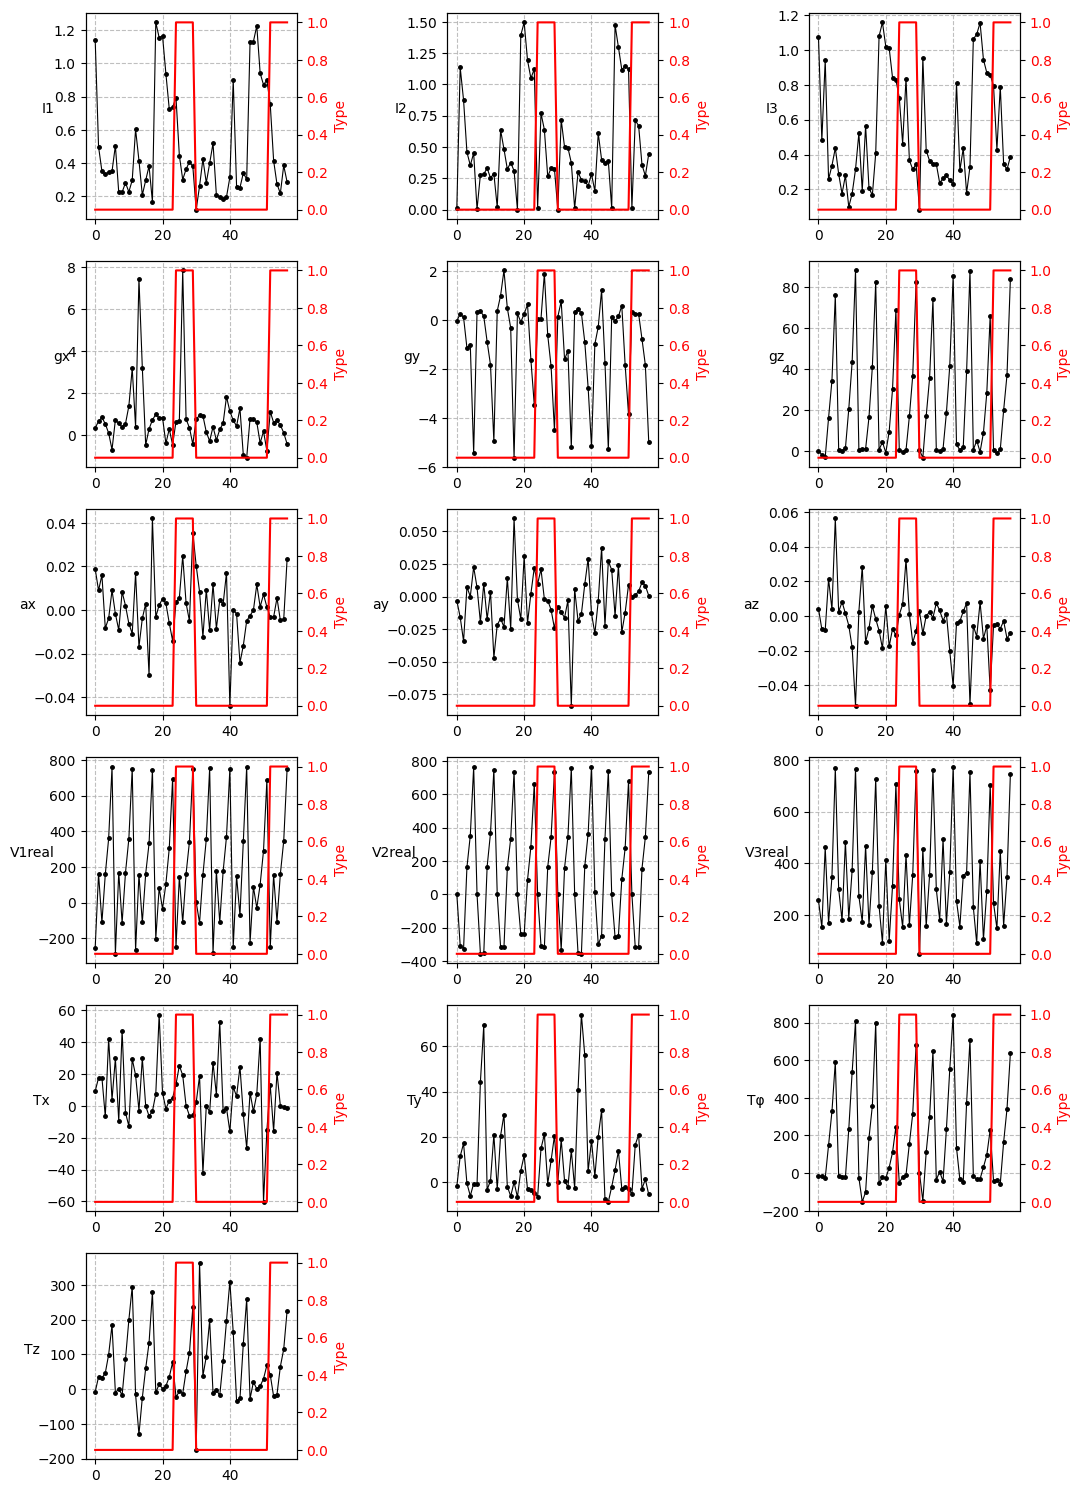

In [30]:
num_columns = V13.select_dtypes(include=np.number).columns.tolist()
num_columns.remove('Type')

cols = 3
rows = len(num_columns) // cols + 1
fig, axes = plt.subplots(rows, cols, figsize=(11, 15))
axes = axes.flatten()

for i, col in enumerate(num_columns):
    ax = axes[i]
    
    ax.plot(V13.index, V13[col], marker='.', linestyle='-', markersize=5, linewidth=0.8, color='black', label=col)
    ax.set_ylabel(col, color='black', rotation=0)
    ax.tick_params(axis='y', labelcolor='black')
    ax.grid(True, linestyle='--', alpha=0.8)

    ax2 = ax.twinx()
    ax2.plot(V13.index, V13['Type'], linestyle='-', linewidth=1.5, color='red', label='Type')
    ax2.set_ylabel('Type', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

axes[len(axes) - 1].axis('off')
axes[len(axes) - 2].axis('off')
plt.tight_layout()
plt.show()

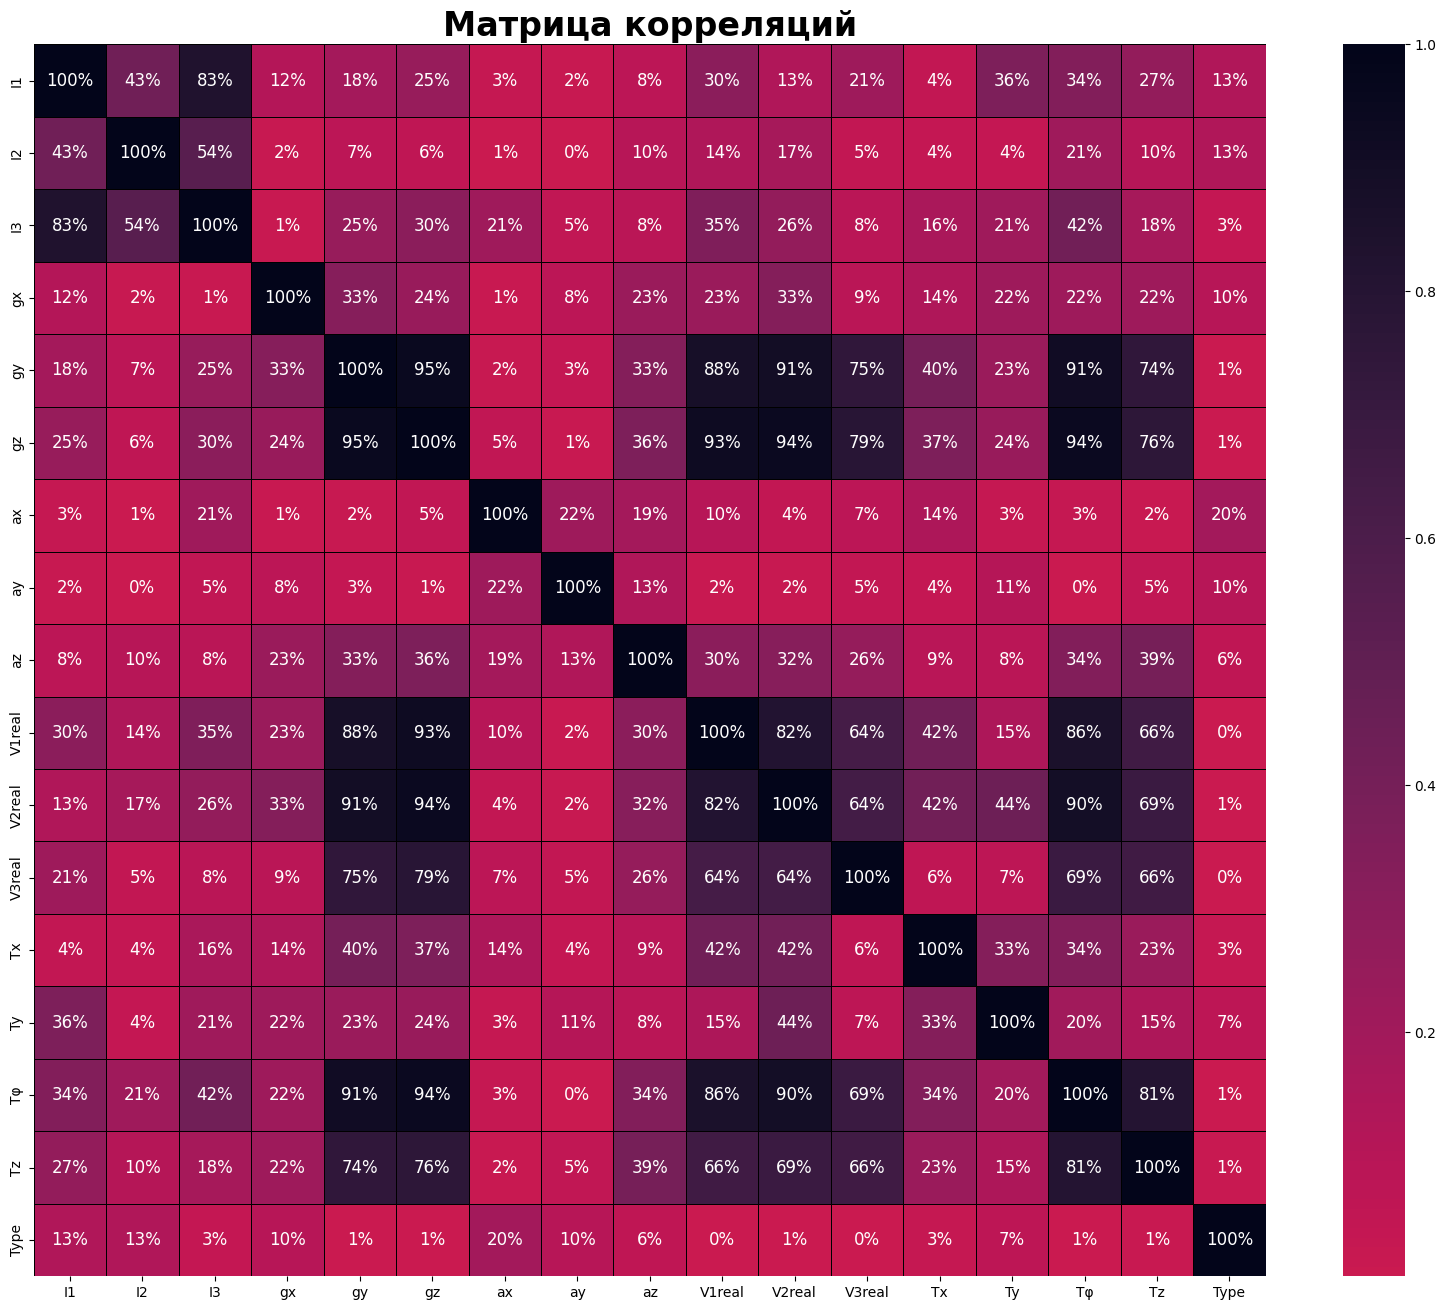

In [31]:
num_columns = V13.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(20, 16))
sns.heatmap(abs(V13[num_columns].corr()), 
            annot=True, 
            cbar=True,
            cmap='rocket_r', 
            center=0,
            fmt='.0%',
            annot_kws={'size':str(12)},
            square=True,
            linewidths=0.5,
            linecolor='black')
plt.title('Матрица корреляций', fontdict={'fontsize': 24, 'fontweight': 'bold'})
plt.show()

## Часть 2. Работа с MLPClassifier

### <font color='#F5DEB3'> Подготовка данных и модели

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [33]:
target_col = [config['data']['target_column']]
feature_cols = [col for col in V13.columns if col not in target_col]

data_x = np.array(V13.drop(target_col, axis=1))
data_y = np.array(V13[target_col]).ravel()

data_x_AB = np.array(V13_AB.drop(target_col, axis=1))
data_y_AB = np.array(V13_AB[target_col]).ravel()

In [34]:
scaler = MinMaxScaler()
adasyn = ADASYN(random_state=42)
smote = SMOTE(random_state=42)

data_x_scaled_AB = scaler.fit_transform(data_x_AB)
data_x_scaled_C = scaler.fit_transform(data_x)
X_adasyn, Y_adasyn = adasyn.fit_resample(data_x_scaled_AB, data_y_AB)
X_smote, Y_smote = smote.fit_resample(data_x_scaled_AB, data_y_AB)

#### <font color='#F5DEB3'> Тестирование на неизвестном наборе данных

In [35]:
def plot_train_test_predictions(
    data_x_AB, data_y_AB,   
    data_x_C, data_y_C,         
    parameters,
    random_state=42,
    n_show=None
):
    mlp = MLPClassifier(**parameters, random_state=random_state)
    mlp.fit(data_x_AB, data_y_AB)

    y_pred = mlp.predict(data_x_C)
    acc = accuracy_score(data_y_C, y_pred)
    f1 = f1_score(data_y_C, y_pred, average='binary', zero_division=0)
    print(f"Тест на C: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

    if n_show is None:
        n_show = len(data_y_C)
    else:
        n_show = min(n_show, len(data_y_C))

    indices = np.arange(n_show)

    plt.figure(figsize=(6, 4))
    plt.plot(indices, data_y_C[:n_show], label='Реальные метки (0/1)',
             color='blue', linewidth=2, alpha=0.8)
    plt.plot(indices, y_pred[:n_show], label='Предсказанный класс (0/1)',
             color='red', linewidth=2, alpha=0.8)
    plt.xlabel('Индекс примера')
    plt.ylabel('Класс (0 или 1)')
    plt.title('Сравнение реальных и предсказанных классов на отложенной выборке C')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### <font color='#F5DEB3'> С нормализацией MinMaxScaler и балансировкой SMOTE

Тест на C: Accuracy = 0.8793, F1 = 0.7200


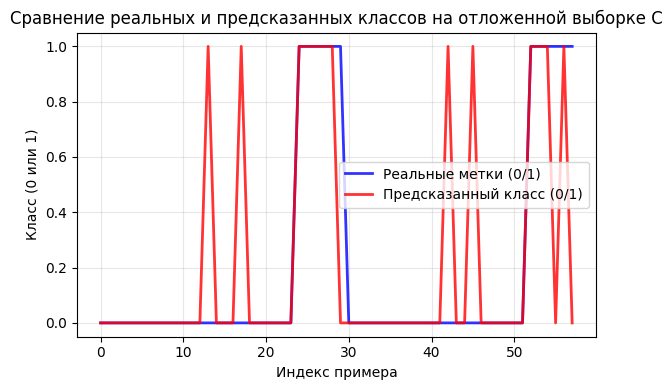

Тест на C: Accuracy = 0.8966, F1 = 0.7000


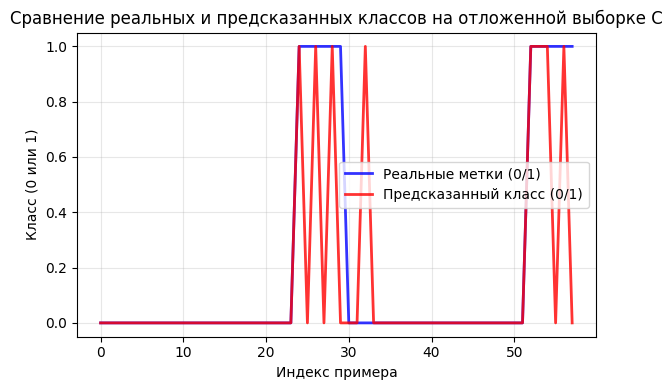

Тест на C: Accuracy = 0.9138, F1 = 0.7368


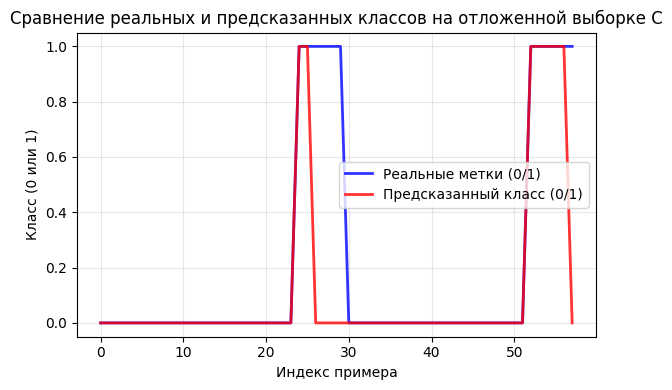

In [36]:
# С нормализацией MinMaxScaler
best_params_1 = {
    'hidden_layer_sizes': (50,), 
    'activation': 'tanh', 
    'solver': 'lbfgs', 
    'max_iter': 500,
    }

best_params_2 = {
    'hidden_layer_sizes': (50, 20), 
    'activation': 'relu', 
    'solver': 'adam', 
    'max_iter': 1000,
    }

best_params_3 = {
    'hidden_layer_sizes': (30, 30, 20), 
    'activation': 'relu', 
    'solver': 'adam', 
    'max_iter': 1000,
    }

plot_train_test_predictions(
    data_x_scaled_AB, data_y_AB,   
    data_x_scaled_C, data_y,   
    best_params_1
)

plot_train_test_predictions(
    data_x_scaled_AB, data_y_AB,   
    data_x_scaled_C, data_y,   
    best_params_2
)

plot_train_test_predictions(
    data_x_scaled_AB, data_y_AB,   
    data_x_scaled_C, data_y,   
    best_params_3
)

Тест на C: Accuracy = 0.8276, F1 = 0.5833


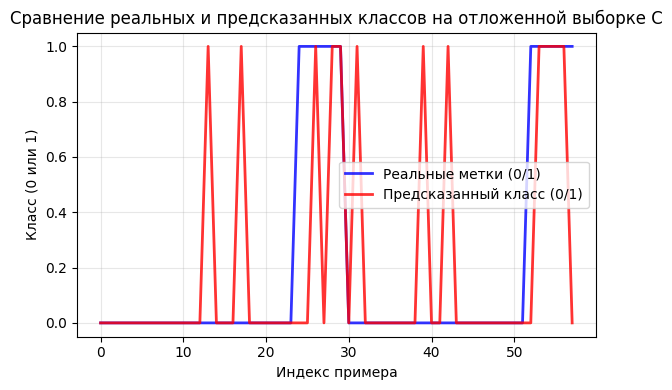

Тест на C: Accuracy = 0.8276, F1 = 0.6154


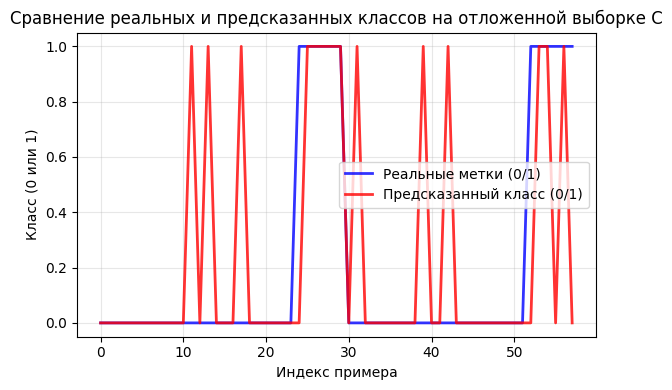

Тест на C: Accuracy = 0.8621, F1 = 0.6667


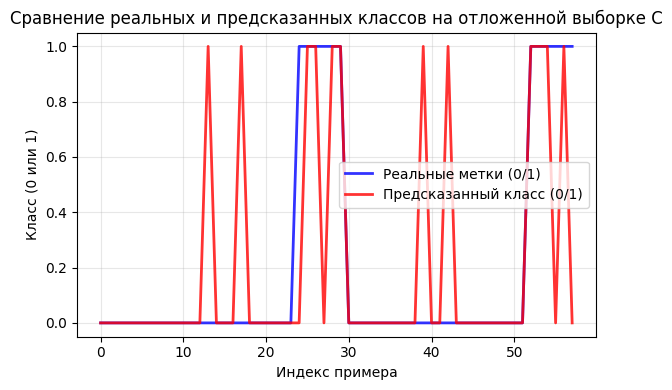

In [21]:
# С нормализацией MinMaxScaler и балансировкой SMOTE
best_params_1 = {
    'hidden_layer_sizes': (150,), 
    'activation': 'tanh', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    }

best_params_2 = {
    'hidden_layer_sizes': (40, 30), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    }

best_params_3 = {
    'hidden_layer_sizes': (48, 48, 32), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    }

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_C, data_y,   
    best_params_1
)

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_C, data_y,   
    best_params_2
)

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_C, data_y,   
    best_params_3
)

#### <font color='#F5DEB3'> С нормализацией MinMaxScaler и балансировкой ADASYN

Тест на C: Accuracy = 0.8793, F1 = 0.7200


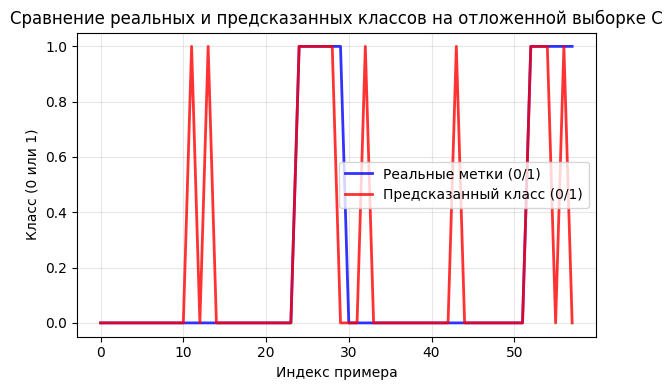

Тест на C: Accuracy = 0.8793, F1 = 0.6316


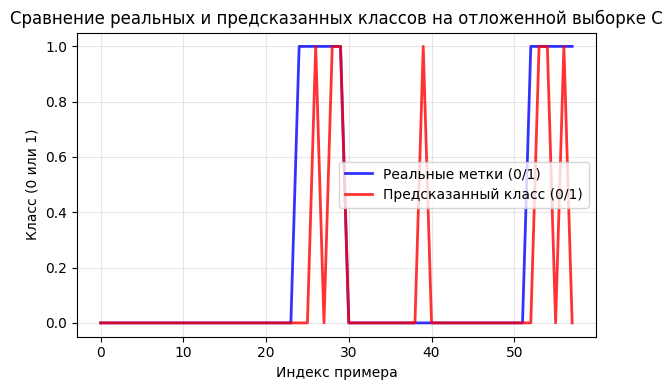

Тест на C: Accuracy = 0.8793, F1 = 0.7200


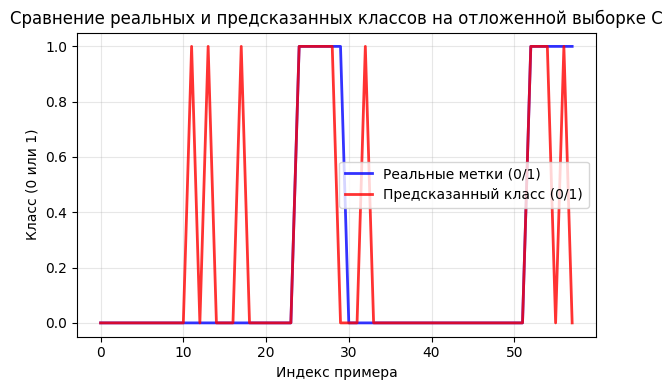

In [22]:
# С нормализацией MinMaxScaler и балансировкой ADASYN
best_params_1 = {
    'hidden_layer_sizes': (200,), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    }

best_params_2 = {
    'hidden_layer_sizes': (40, 30), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    }

best_params_3 = {
    'hidden_layer_sizes': (48, 48, 32), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    }

plot_train_test_predictions(
    X_adasyn, Y_adasyn,   
    data_x_scaled_C, data_y,   
    best_params_1
)

plot_train_test_predictions(
    X_adasyn, Y_adasyn,    
    data_x_scaled_C, data_y,   
    best_params_2
)

plot_train_test_predictions(
    X_adasyn, Y_adasyn,    
    data_x_scaled_C, data_y,   
    best_params_3
)

#### <font color='#F5DEB3'> С нормализацией MinMaxScaler и балансировкой SMOTE + Optuna

Тест на C: Accuracy = 0.8966, F1 = 0.7500


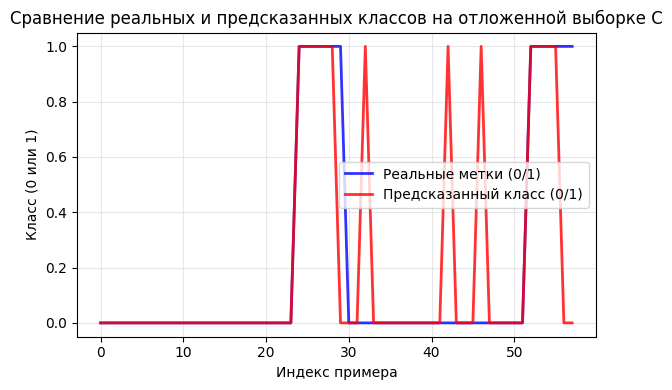

Тест на C: Accuracy = 0.8966, F1 = 0.7273


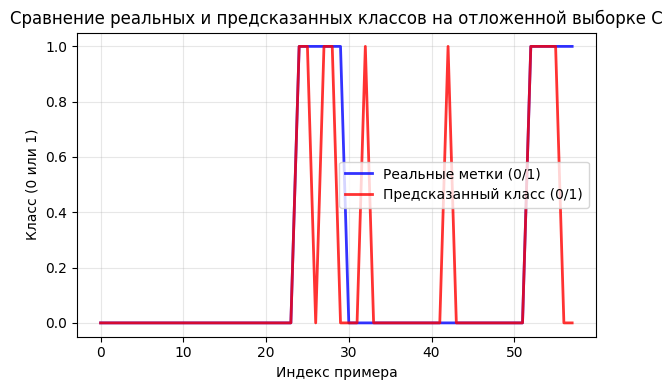

Тест на C: Accuracy = 0.9655, F1 = 0.9167


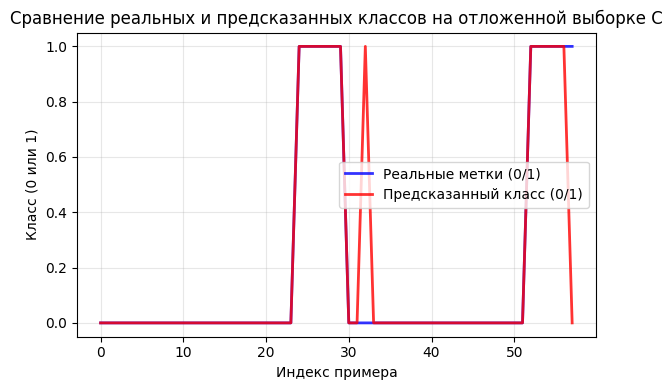

In [23]:
# С нормализацией MinMaxScaler и балансировкой SMOTE
best_params_1 = {
    'hidden_layer_sizes': (63,), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 470,
    'alpha': 0.0006169778
    }

best_params_2 = {
    'hidden_layer_sizes': (30, 19), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 600,
    'alpha': 0.0035987656
    }

best_params_3 = {
    'hidden_layer_sizes': (30, 51, 49), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 670,
    'alpha': 0.0126914484
    }

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_C, data_y,   
    best_params_1
)

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_C, data_y,   
    best_params_2
)

plot_train_test_predictions(
    X_smote, Y_smote,   
    data_x_scaled_C, data_y,   
    best_params_3
)

#### <font color='#F5DEB3'> С нормализацией MinMaxScaler и балансировкой ADASYN + Optuna

Тест на C: Accuracy = 0.8793, F1 = 0.6957


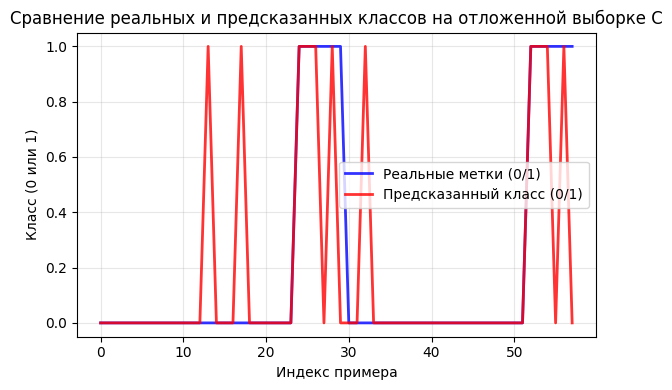

Тест на C: Accuracy = 0.8276, F1 = 0.5833


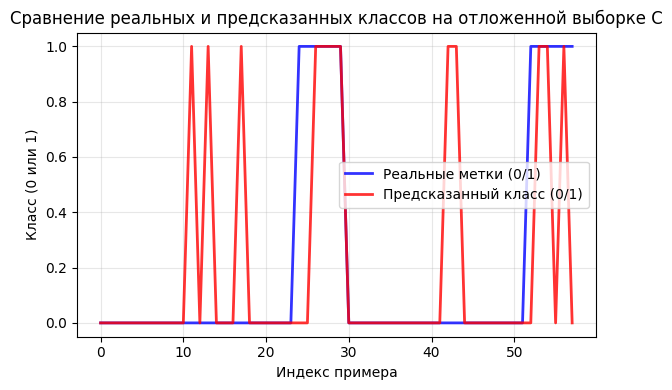

Тест на C: Accuracy = 0.8448, F1 = 0.5714


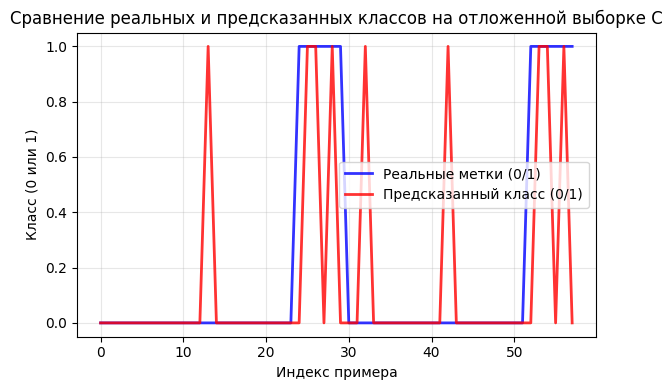

In [24]:
# С нормализацией MinMaxScaler и балансировкой ADASYN
best_params_1 = {
    'hidden_layer_sizes': (66,), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 230,
    'alpha': 0.0032129369
    }

best_params_2 = {
    'hidden_layer_sizes': (57, 30), 
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 190,
    'alpha': 0.0320593885
    }

best_params_3 = {
    'hidden_layer_sizes': (60, 60, 56), 
    'activation': 'tanh', 
    'solver': 'lbfgs', 
    'max_iter': 540,
    'alpha': 0.0013197827
    }

plot_train_test_predictions(
    X_adasyn, Y_adasyn,   
    data_x_scaled_C, data_y,   
    best_params_1
)

plot_train_test_predictions(
    X_adasyn, Y_adasyn,    
    data_x_scaled_C, data_y,   
    best_params_2
)

plot_train_test_predictions(
    X_adasyn, Y_adasyn,    
    data_x_scaled_C, data_y,   
    best_params_3
)

#### <font color='#F5DEB3'> С нормализацией MinMaxScaler и балансировкой ADASYN + собственные значения

Тест на C: Accuracy = 0.9138, F1 = 0.8000


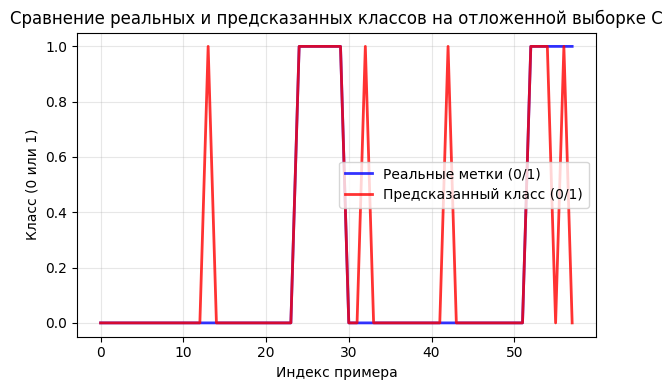

In [25]:
best_params = {
    'hidden_layer_sizes': (30, 30, 20),
    'activation': 'relu', 
    'solver': 'lbfgs', 
    'max_iter': 1000,
    'alpha': 0.00016077399
    }

plot_train_test_predictions(
    X_adasyn, Y_adasyn,    
    data_x_scaled_C, data_y,   
    best_params,
)